# 02 — Bayesian Payroll Efficiency (Pillar 1)
**Question:** Which Mariners contracts are high-confidence over/underperforming?

**Approach:** Hierarchical Bayesian model. Player true-talent WAR ~ position + age + sample size, partial pooling toward position means. Output: posterior $/WAR with credible intervals for every Mariners player.

In [1]:
import sys
sys.path.insert(0, "..")

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from src.ingest.pull_data import get_db

try:
    con = get_db(read_only=True)
except duckdb.IOException as e:
    print("⚠  DuckDB lock error:", e)
    print()
    print("A write-mode connection is still open somewhere. To find and kill it:")
    print("  ! lsof ../data/mariners.duckdb")
    print("  ! kill <PID from above>")
    print()
    print("Or restart the kernel of the other notebook, then re-run this cell.")
    raise

roster = con.execute("""
    SELECT
        ps.season,
        ps.mlbam_id,
        p.name_full,
        p.position,
        ps.age,
        ps.pa,
        ps.war,
        ps.woba,
        ps.wrc_plus,
        c.aav_m,
        c.total_value_m,
        c.years AS contract_years,
        c.contract_type,
        c.season_start,
        c.season_end
    FROM player_seasons ps
    JOIN players p USING (mlbam_id)
    LEFT JOIN contracts c USING (mlbam_id)
    WHERE ps.is_mariners = TRUE
    ORDER BY ps.season DESC, ps.war DESC
""").fetchdf()

print(f"{len(roster)} player-seasons  |  {roster['mlbam_id'].nunique()} unique players")
print(f"Players with contract data: {roster['aav_m'].notna().sum()}")
roster.head(10)

262 player-seasons  |  142 unique players
Players with contract data: 38


,season,mlbam_id,name_full,position,age,pa,war,woba,wrc_plus,aav_m,total_value_m,contract_years,contract_type,season_start,season_end
0,2026,670042,Luke Raley,1B/OF,31,72,0.838804,0.439165,190,2.0500,2.0500,1,arbitration,2026,2026
1,2026,668227,Randy Arozarena,OF,31,93,0.664493,0.359546,136,15.6500,15.6500,1,arbitration,2026,2026
2,2026,680977,Brendan Donovan,2B/OF,29,71,0.642944,0.426245,182,5.8000,5.8000,1,arbitration,2026,2026
3,2026,702284,Cole Young,2B,22,86,0.503899,0.334555,119,NaN,NaN,<NA>,None,<NA>,<NA>
4,2026,663728,Cal Raleigh,C,29,96,0.238107,0.241122,55,17.5000,105.0000,6,extension,2025,2030
5,2026,686527,Dominic Canzone,OF,28,53,0.187367,0.354289,132,0.7966,0.7966,1,arbitration,2026,2026
6,2026,641487,J.P. Crawford,SS,31,56,0.055668,0.319054,108,10.2000,51.0000,5,extension,2022,2026
7,2026,660844,Leo Rivas,2B/SS,28,57,0.038355,0.248761,61,NaN,NaN,<NA>,None,<NA>,<NA>
8,2026,677594,Julio Rodriguez,OF,25,95,-0.022894,0.272827,77,17.4417,209.3000,12,extension,2023,2034
9,2026,621550,Patrick Wisdom,3B,34,1,-0.031992,0.000000,-100,1.0000,1.0000,1,FA,2026,2026


## 1 — Payroll Distribution

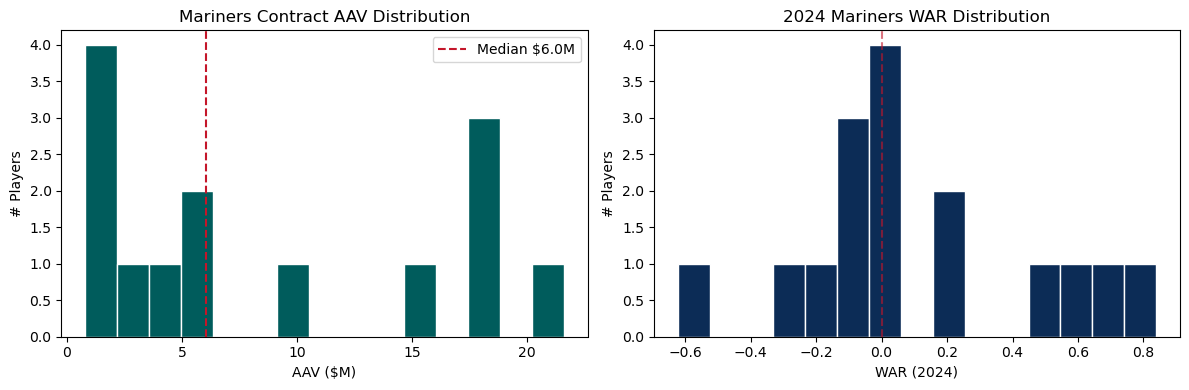


Contracts on books: 14
      name_full position contract_type   aav_m  contract_years  season_start  season_end
  Luis Castillo        P     extension 21.6000               5          2023        2028
    Josh Naylor       1B            FA 18.5000               5          2026        2030
    Cal Raleigh        C     extension 17.5000               6          2025        2030
Julio Rodriguez       OF     extension 17.4417              12          2023        2034
Randy Arozarena       OF   arbitration 15.6500               1          2026        2026
  J.P. Crawford       SS     extension 10.2000               5          2022        2026
  Rob Refsnyder       OF            FA  6.2500               1          2026        2026
Brendan Donovan    2B/OF   arbitration  5.8000               1          2026        2026
  Victor Robles       OF     extension  4.8750               2          2025        2027
   Mitch Garver     C/DH            FA  2.2500               1          2026        20

In [2]:
# Contracts snapshot: one row per player (latest season for those with a contract)
contracts_now = (
    roster.dropna(subset=["aav_m"])
    .sort_values("season", ascending=False)
    .drop_duplicates(subset=["mlbam_id"])
    .copy()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- AAV distribution ---
ax = axes[0]
ax.hist(contracts_now["aav_m"], bins=15, color="#005C5C", edgecolor="white")
ax.set_xlabel("AAV ($M)")
ax.set_ylabel("# Players")
ax.set_title("Mariners Contract AAV Distribution")
median_aav = contracts_now["aav_m"].median()
ax.axvline(median_aav, color="#C4162A", linestyle="--", label=f"Median ${median_aav:.1f}M")
ax.legend()

# --- WAR distribution (most recent season) ---
ax = axes[1]
recent = roster[roster["season"] == roster["season"].max()].copy()
ax.hist(recent["war"].dropna(), bins=15, color="#0C2C56", edgecolor="white")
ax.set_xlabel("WAR (2024)")
ax.set_ylabel("# Players")
ax.set_title("2024 Mariners WAR Distribution")
ax.axvline(0, color="#C4162A", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"\nContracts on books: {len(contracts_now)}")
print(contracts_now[["name_full","position","contract_type","aav_m","contract_years","season_start","season_end"]]
      .sort_values("aav_m", ascending=False).to_string(index=False))

## 2 — WAR vs AAV (face-value efficiency)

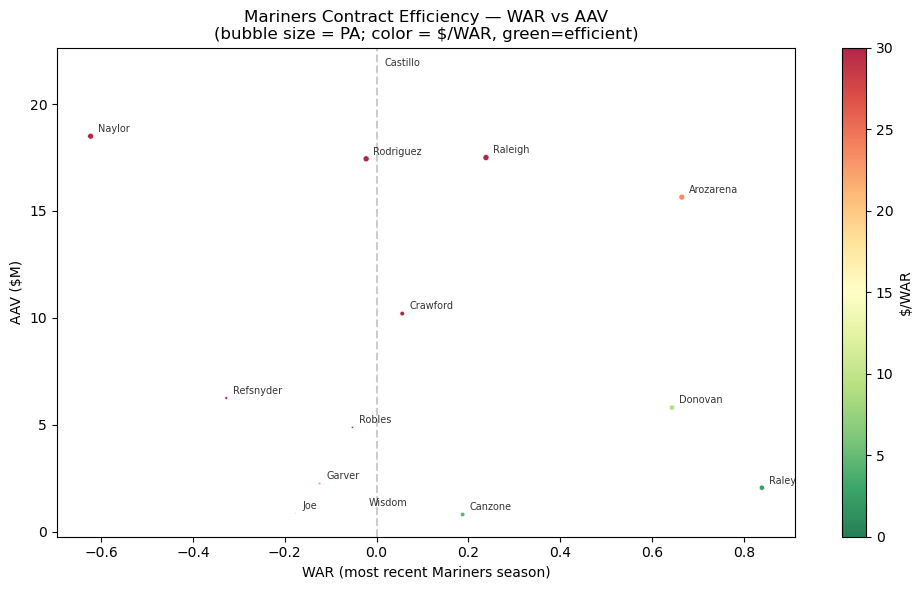

In [3]:
# Most recent season with both WAR and contract data
plot_df = (
    roster.dropna(subset=["war", "aav_m"])
    .sort_values("season", ascending=False)
    .drop_duplicates(subset=["mlbam_id"])
    .copy()
)
plot_df["dollars_per_war"] = plot_df["aav_m"] / plot_df["war"].clip(lower=0.1)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    plot_df["war"], plot_df["aav_m"],
    s=plot_df["pa"].fillna(300) / 5,
    c=plot_df["dollars_per_war"],
    cmap="RdYlGn_r", vmin=0, vmax=30,
    alpha=0.85, edgecolors="white", linewidths=0.5,
)
plt.colorbar(scatter, ax=ax, label="$/WAR")

# Label notable players
for _, row in plot_df.iterrows():
    ax.annotate(
        row["name_full"].split()[-1],
        (row["war"], row["aav_m"]),
        textcoords="offset points", xytext=(5, 3),
        fontsize=7, alpha=0.8,
    )

ax.axvline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("WAR (most recent Mariners season)")
ax.set_ylabel("AAV ($M)")
ax.set_title("Mariners Contract Efficiency — WAR vs AAV\n(bubble size = PA; color = $/WAR, green=efficient)")
plt.tight_layout()
plt.show()

In [4]:
# ── Emergency toggle ──────────────────────────────────────────────────────
# Flip to True to skip C compilation entirely — model runs slower but immediately
USE_VM_FALLBACK = False
# ──────────────────────────────────────────────────────────────────────────
import os, shutil, subprocess
import pytensor

# Nuclear cache clean — wipe compiledir AND its parent so no stale .so or
# lock files from previous failed builds survive into this session
for d in [pytensor.config.compiledir,
          getattr(pytensor.config, "base_compiledir", None)]:
    if d and os.path.exists(d):
        shutil.rmtree(d)
        print(f"Cleared: {d}")

if USE_VM_FALLBACK:
    pytensor.config.linker = "vm"
    print("VM fallback active — C compilation bypassed, sampling will be slower")
else:
    sdk = subprocess.check_output(["xcrun", "--show-sdk-path"], text=True).strip()

    os.environ["SDKROOT"]             = sdk
    os.environ["CONDA_BUILD_SYSROOT"] = sdk

    pytensor.config.cxx = "/usr/bin/clang++"
    pytensor.config.gcc__cxxflags = (
        f"-stdlib=libc++ "
        f"-isysroot {sdk} "
        f"-I{sdk}/usr/include/c++/v1"
    )

    python_h = "/opt/anaconda3/include/python3.12/Python.h"
    if not os.path.exists(python_h):
        print(f"WARNING: Python.h not found at {python_h}")

    # -isysroot and its value must be separate list elements (not -isysroot=path)
    probe = subprocess.run(
        ["/usr/bin/clang++",
         "-isysroot", sdk,
         f"-I{sdk}/usr/include/c++/v1",
         "-stdlib=libc++",
         "-x", "c++", "-fsyntax-only", "-"],
        input="#include <vector>\n#include <stdlib.h>\nint main(){}",
        capture_output=True, text=True,
    )
    if probe.returncode == 0:
        print(f"SDK:      {sdk}")
        print(f"Compiler: {pytensor.config.cxx}")
        print(f"Flags:    {pytensor.config.gcc__cxxflags}")
        print("✓ Compiler probe passed — ready to sample")
    else:
        print("✗ Probe failed — activating VM fallback")
        print(probe.stderr[:400])
        pytensor.config.linker = "vm"

Cleared: /Users/owen/.pytensor/compiledir_macOS-15.7.4-arm64-arm-64bit-arm-3.12.13-64
Cleared: /Users/owen/.pytensor
SDK:      /Library/Developer/CommandLineTools/SDKs/MacOSX.sdk
Compiler: /usr/bin/clang++
Flags:    -stdlib=libc++ -isysroot /Library/Developer/CommandLineTools/SDKs/MacOSX.sdk -I/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/include/c++/v1
✓ Compiler probe passed — ready to sample


## 3 — Hierarchical Bayesian Model

Hierarchical structure: each player's true-talent WAR is drawn from a position-group distribution, which is itself drawn from a league-wide hyperprior. This gives partial pooling — a player with 80 PA shrinks more toward the position mean than one with 650 PA.

Run pm.sample() once you've worked through PyMC hierarchical model examples (Statistical Rethinking ch. 13 or PyMC "A Primer on Bayesian Methods").

In [5]:
import pymc as pm
import pytensor.tensor as pt

model_df = (
    roster.dropna(subset=["war", "pa"])
    .query("pa >= 50")
    .copy()
)

pos_map = {
    "C": "C", "1B": "1B", "2B": "2B", "3B": "3B", "SS": "SS",
    "LF": "OF", "CF": "OF", "RF": "OF", "DH": "DH",
    "SP": "SP", "RP": "RP",
}
model_df["pos_group"] = model_df["position"].map(pos_map).fillna("UT")
positions = model_df["pos_group"].unique().tolist()
pos_idx = model_df["pos_group"].map({p: i for i, p in enumerate(positions)}).values
pa_norm = (model_df["pa"] / model_df["pa"].max()).values
war_obs = model_df["war"].values
n_pos   = len(positions)

print(f"Model input: {len(model_df)} player-seasons  |  {n_pos} position groups")
print(f"Positions: {positions}")

with pm.Model() as war_model:
    mu_league    = pm.Normal("mu_league",    mu=1.5, sigma=1.0)
    sigma_league = pm.HalfNormal("sigma_league", sigma=1.0)
    mu_pos    = pm.Normal("mu_pos",    mu=mu_league, sigma=sigma_league, shape=n_pos)
    sigma_pos = pm.HalfNormal("sigma_pos", sigma=0.5, shape=n_pos)
    true_war  = pm.Normal("true_war",
                          mu=mu_pos[pos_idx],
                          sigma=sigma_pos[pos_idx],
                          shape=len(model_df))
    sigma_obs = pm.Deterministic("sigma_obs", 1.5 / pt.sqrt(pa_norm * model_df["pa"].max()))
    war_hat   = pm.Normal("war_hat", mu=true_war, sigma=sigma_obs, observed=war_obs)

print(war_model.debug())
print("\nModel compiled. Run the sampling cell when ready.")

Model input: 167 player-seasons  |  6 position groups
Positions: ['UT', '2B', 'C', 'SS', '1B', '3B']
point={'mu_league': array(1.5), 'sigma_league_log__': array(0.), 'mu_pos': array([1.5, 1.5, 1.5, 1.5, 1.5, 1.5]), 'sigma_pos_log__': array([-0.69314718, -0.69314718, -0.69314718, -0.69314718, -0.69314718,
       -0.69314718]), 'true_war': array([1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 

## 4 — Sampling (run after PyMC study)

Uncomment the cell below once you're comfortable with NUTS / MCMC convergence diagnostics. Expected runtime: ~3-5 minutes on a laptop.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_league, sigma_league, mu_pos, sigma_pos, true_war]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.


,mlbam_id,name_full,pos_group,season,aav_m,contract_years,war_posterior_mean,war_hdi_lo,war_hdi_hi,dollars_per_war_posterior
15,686527,Dominic Canzone,UT,2025,0.7966,1,1.480444,1.298499,1.645606,0.538082
26,670042,Luke Raley,UT,2024,2.0500,1,2.262662,2.136335,2.393025,0.906013
10,663728,Cal Raleigh,C,2025,17.5000,6,9.054682,8.949013,9.162108,1.932702
37,641487,J.P. Crawford,SS,2023,10.2000,5,4.836190,4.726251,4.949284,2.109098
0,670042,Luke Raley,UT,2026,2.0500,1,0.840812,0.534409,1.171729,2.438119
36,677594,Julio Rodriguez,UT,2023,17.4417,12,5.824758,5.723166,5.930740,2.994408
50,677594,Julio Rodriguez,UT,2022,17.4417,12,5.730286,5.604108,5.847795,3.043775
11,677594,Julio Rodriguez,UT,2025,17.4417,12,5.720810,5.612397,5.826441,3.048817
23,663728,Cal Raleigh,C,2024,17.5000,6,5.403279,5.287414,5.516087,3.238774
67,641487,J.P. Crawford,SS,2021,10.2000,5,3.060857,2.957738,3.167652,3.332401


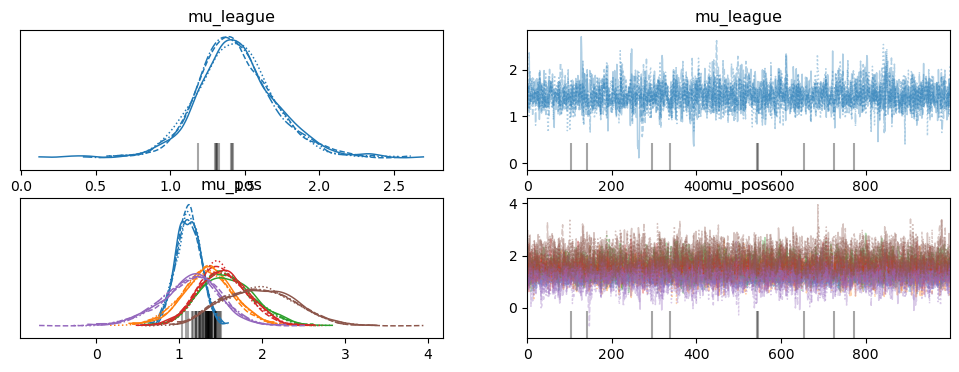

In [6]:
import arviz as az

with war_model:
    idata = pm.sample(draws=1000, tune=1000, chains=4,
                      target_accept=0.98, random_seed=42)

az.plot_trace(idata, var_names=["mu_league", "mu_pos"])
az.summary(idata, var_names=["mu_league", "mu_pos", "sigma_pos"])

# --- Post-sampling: extract posterior $/WAR per player ---
true_war_post = idata.posterior["true_war"].values  # shape: (chains, draws, n_players)
true_war_mean = true_war_post.mean(axis=(0, 1))
true_war_hdi  = az.hdi(idata, var_names=["true_war"])["true_war"].values

results = model_df[["mlbam_id", "name_full", "pos_group", "season",
                     "aav_m", "contract_years"]].copy().reset_index(drop=True)
results["war_posterior_mean"] = true_war_mean
results["war_hdi_lo"] = true_war_hdi[:, 0]
results["war_hdi_hi"] = true_war_hdi[:, 1]
results["dollars_per_war_posterior"] = (
    results["aav_m"] / results["war_posterior_mean"].clip(lower=0.1)
)
results.sort_values("dollars_per_war_posterior").head(20)

In [7]:
# --- Summary: Value Bargains & High-Confidence Underperformers ---
league_avg_war = float(idata.posterior["mu_league"].values.mean())

# One row per player: keep the most recent season's posterior estimate
results_latest = (
    results.sort_values("season")
    .drop_duplicates(subset=["mlbam_id"], keep="last")
    .reset_index(drop=True)
)

# Top 5 Value Bargains: highest posterior WAR relative to AAV (lowest $/WAR)
bargains = (
    results_latest.dropna(subset=["aav_m"])
    .sort_values("dollars_per_war_posterior")
    .head(5)
)
print("=== Top 5 Value Bargains (lowest $/WAR) ===")
print(bargains[["name_full", "pos_group", "aav_m",
                "war_posterior_mean", "dollars_per_war_posterior"]].to_string(index=False))

# Top 5 High-Confidence Underperformers:
#   94% HDI entirely below league average WAR, sorted by worst $/WAR
underperformers = (
    results_latest.dropna(subset=["aav_m"])
    .loc[lambda df: df["war_hdi_hi"] < league_avg_war]
    .sort_values("dollars_per_war_posterior", ascending=False)
    .head(5)
)
print(f"\n=== Top 5 High-Confidence Underperformers "
      f"(94% HDI entirely below league avg {league_avg_war:.2f} WAR) ===")
print(underperformers[["name_full", "pos_group", "aav_m",
                        "war_posterior_mean", "war_hdi_lo", "war_hdi_hi",
                        "dollars_per_war_posterior"]].to_string(index=False))

=== Top 5 Value Bargains (lowest $/WAR) ===
      name_full pos_group   aav_m  war_posterior_mean  dollars_per_war_posterior
     Luke Raley        UT  2.0500            0.840812                   2.438119
Dominic Canzone        UT  0.7966            0.202051                   3.942570
Brendan Donovan        UT  5.8000            0.647991                   8.950740
   Mitch Garver        UT  2.2500           -0.036101                  22.500000
Randy Arozarena        UT 15.6500            0.669236                  23.384885

=== Top 5 High-Confidence Underperformers (94% HDI entirely below league avg 1.44 WAR) ===
      name_full pos_group   aav_m  war_posterior_mean  war_hdi_lo  war_hdi_hi  dollars_per_war_posterior
    Josh Naylor        1B 18.5000           -0.590029   -0.888756   -0.304977                 185.000000
Julio Rodriguez        UT 17.4417           -0.008700   -0.305347    0.262760                 174.417000
  J.P. Crawford        SS 10.2000            0.094821   -0.2733

In [8]:
# --- Export to Tableau ---
export_path = "../dashboard/tableau_data_extracts/payroll_efficiency.csv"
results_latest.to_csv(export_path, index=False)
print(f"Exported {len(results_latest)} rows to {export_path}")
print(results_latest.columns.tolist())

Exported 83 rows to ../dashboard/tableau_data_extracts/payroll_efficiency.csv
['mlbam_id', 'name_full', 'pos_group', 'season', 'aav_m', 'contract_years', 'war_posterior_mean', 'war_hdi_lo', 'war_hdi_hi', 'dollars_per_war_posterior']


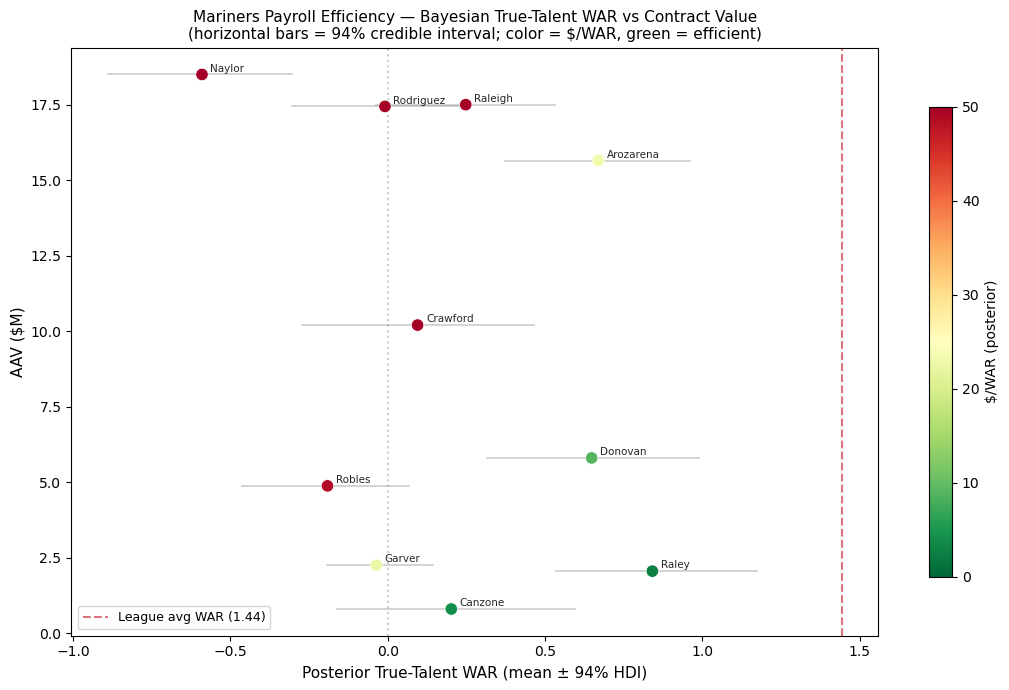

In [9]:
# --- Hero chart: Posterior WAR vs AAV with HDI uncertainty bands ---
plot_results = results_latest.dropna(subset=["aav_m"]).copy()

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    plot_results["war_posterior_mean"],
    plot_results["aav_m"],
    c=plot_results["dollars_per_war_posterior"].clip(upper=50),
    cmap="RdYlGn_r", vmin=0, vmax=50,
    s=80, zorder=3, edgecolors="white", linewidths=0.5,
)
plt.colorbar(scatter, ax=ax, label="$/WAR (posterior)", shrink=0.8)

# HDI error bars (horizontal)
for _, row in plot_results.iterrows():
    ax.plot(
        [row["war_hdi_lo"], row["war_hdi_hi"]],
        [row["aav_m"], row["aav_m"]],
        color="gray", alpha=0.4, linewidth=1.2, zorder=2,
    )

# Player labels
for _, row in plot_results.iterrows():
    ax.annotate(
        row["name_full"].split()[-1],
        (row["war_posterior_mean"], row["aav_m"]),
        textcoords="offset points", xytext=(6, 2),
        fontsize=7.5, alpha=0.85,
    )

ax.axvline(league_avg_war, color="#C4162A", linestyle="--", alpha=0.6,
           label=f"League avg WAR ({league_avg_war:.2f})")
ax.axvline(0, color="gray", linestyle=":", alpha=0.4)

ax.set_xlabel("Posterior True-Talent WAR (mean ± 94% HDI)", fontsize=11)
ax.set_ylabel("AAV ($M)", fontsize=11)
ax.set_title(
    "Mariners Payroll Efficiency — Bayesian True-Talent WAR vs Contract Value\n"
    "(horizontal bars = 94% credible interval; color = $/WAR, green = efficient)",
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../dashboard/tableau_data_extracts/payroll_efficiency_chart.png",
            dpi=150, bbox_inches="tight")
plt.show()